## Libraries

In [1]:
import os

In [2]:
run = 'local' #local or cloud
os.environ["APP_ENV"] = run

In [3]:
import sys
sys.path.append('..')

In [4]:
from src.grass_functions import*
from src.process_inputs import*
%matplotlib inline
#%load_ext autoreload
#%autoreload 2

C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\db.py:147: SyntaxWarning: invalid escape sequence '\g'
  :param str args:  see \gmod{db.select} arguments
C:\Program Files\GRASS GIS 7.8\etc\python\grass\script\setup.py:30: SyntaxWarning: invalid escape sequence '\O'
  grass7bin = r'C:\OSGeo4W\bin\grass78.bat'
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\parameter.py:141: SyntaxWarning: invalid escape sequence '\d'
  isrange = re.match("(?P<min>-*\d+.*\d*)*-(?P<max>\d+.*\d*)*",
C:\Program Files\GRASS GIS 7.8\etc\python\grass\pygrass\modules\interface\module.py:233: SyntaxWarning: invalid escape sequence '\_'
  To run the Module objects in parallel the run\_ and finish\_ options


# Parameters

In [10]:
#set project variables
Project_Area = 'lau'
projection = '5070' #set to None if you want to use the DEM's original projection
res = '1m'

## Set variables analysis
source = 'wbd' #wbd or user-defined
data_scale = 'HUC12' #other options HUC12, HUC10, HUC8 OR the field name of the source data to be split <-- case sensitive
select_data = '020402020603' #     # Value within the filter_field used for data selection
to_headwaters = False #False if only interested in local huc area
input_shp_name = None #None or must be populated populated with a shapefile polygons if data_scale != HUCXX
buffer = 2000
auto_delete = False

In [11]:
if data_scale.find('HUC') >= 0:
    huc_level = re.findall("[0-9]+",data_scale)[0]
    if huc_level == str(len(select_data)):
        huc_digys = huc_level
    else:
        huc_digys = huc_level
        select_data = select_data[:int(huc_digys)]

In [12]:
## Paths:
parent_dir = pl.Path(os.getcwd()).parent/'data'
current_dir = pl.Path(os.getcwd())
outputs_dir =parent_dir/'Rasters'/Project_Area/'Outputs'
vector_dir = parent_dir/'Vectors'/Project_Area
raster_dir = parent_dir/'Rasters'/Project_Area
huc_path = vector_dir/'{}_aoi.geojson'.format(Project_Area)
git_data_repo = current_dir/'data_repository'
if input_shp_name:
    input_shp = vector_dir/input_shp_name
directory = outputs_dir

### Get area of interest

In [13]:
#read from to vector path from notebook 1
huc_path = vector_dir/'{0}_{1}_aoi.geojson'.format(Project_Area,select_data)
aoi = gpd.read_file(str(huc_path),driver="GeoJSON")

C:\Users\Curtis.Smith\AppData\Local\miniforge3\envs\geoenv\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


### Start new grass session

In [14]:
# define GRASS data settings (adapt to your needs)
location = Project_Area+'_'+projection
mapset = 'PERMANENT'

In [15]:
# def initialize_grass_db(location, mapset, georef_file):
#     #Start GRASS GIS session
#     rcfile = gsetup.init(gisbase, gisdb, "nc_basic_spm_grass7", "user1")
    
#     ## Location
#     GrassGIS_Location = os.path.join(gisdb, location)
#     #Location and Mapset
#     GrassGIS_LocationMapset = os.path.join(gisdb, location, mapset)
#     #Setup database for the project. Need to setup the location first, which builds a permanent folder for mapsets
    
#     #Check if the Location is setup. If not setup, create the location for the database
#     if os.path.exists(GrassGIS_Location):
#         print("Database Location Exists")
#     else:
#         with Session(gisdb=gisdb, location=location):
#             gs.run_command('g.proj',location=location,georef=georef_file,flags='c')
#             #gs.run_command('g.mapset', mapset=Mapset, location=Location)
#             # run something in PERMANENT mapset:
#             print(gcore.parse_command("g.gisenv", flags="s"))
            

#     if os.path.exists(GrassGIS_LocationMapset):
#         print("Database Mapset Exists")
#     else:
#         with Session(gisdb=gisdb, location=location, mapset=mapset,create_opts=""):
#             # do something in the test mapset.
#             print(gcore.parse_command("g.gisenv", flags="s"))  
#     # remove old session
#     os.remove(rcfile)
#     #Start new session
#     rcfile = gsetup.init(gisbase,gisdb, location, mapset)
#     # example calls
#     print(gs.message('Current GRASS GIS 7 environment:'))
#     print (gs.gisenv())

In [18]:
initialize_grass_db(location, mapset, projection)
#initialize_grass_db(location, mapset, projection)

{'GISDBASE': "'C:\\Users\\Curtis.Smith\\Documents\\grassdata';", 'LOCATION_NAME': "'lau_5070';", 'MAPSET': "'PERMANENT';"}
Database Mapset Exists
None
{'GISDBASE': 'C:\\Users\\Curtis.Smith\\Documents\\grassdata', 'LOCATION_NAME': 'lau_5070', 'MAPSET': 'PERMANENT'}


In [12]:
#gisrc = gs.setup.init(gisbase,gisdb,location, mapset)

#### Review existing files

In [19]:
gs.run_command('g.remove',type='raster',name='None',flags='f')

0

In [20]:
#list all grass files
grass_maps = list_existing_grass(print_it=True)

Available vector maps:

Available raster maps:


In [21]:
# import os
# import sys
# import tempfile as tmpfile


# windows = sys.platform == 'win32'
# def write_gisrc(dbase, location, mapset):
#     """Write the ``gisrc`` file and return its path."""
#     gisrc = tmpfile.mktemp()
#     with open(gisrc, 'w') as rc:
#         rc.write("GISDBASE: %s\n" % dbase)
#         rc.write("LOCATION_NAME: %s\n" % location)
#         rc.write("MAPSET: %s\n" % mapset)
#     return gisrc



# def set_gui_path():
#     """Insert wxPython GRASS path to sys.path."""
#     gui_path = os.path.join(os.environ['GISBASE'], 'gui', 'wxpython')
#     if gui_path and gui_path not in sys.path:
#         sys.path.insert(0, gui_path)

In [22]:
basin_list = aoi[data_scale.lower()].to_list()
basins = 'aoi'
gs.parse_command('v.import', input= huc_path,  output= basins)
print('added aoi to grass')

added aoi to grass


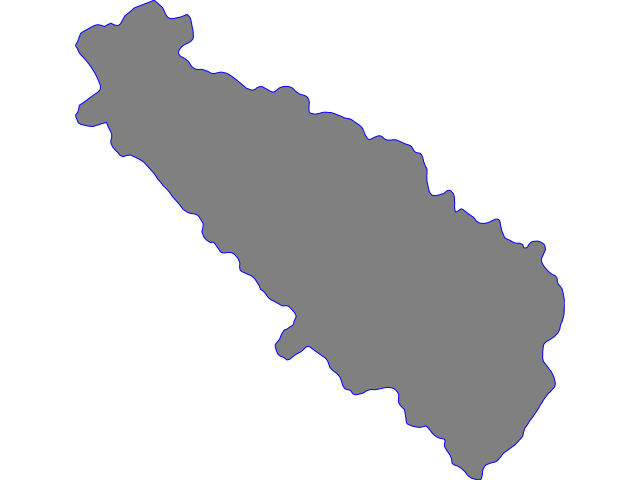

In [23]:
##print basins in grass @ Regional scale to confirm data and extent
gs.parse_command('g.region',vector = basins)
gs.run_command('d.erase')

#gs.run_command('d.vect', map='tmp_bsn_buffer',color='red',fill_color='gray')
gs.run_command('d.vect', map= basins,color='blue',fill_color='gray')

Image(filename="map.png")

### Get Raster data

#### Must first run DEM Download Notebook at
[DEM Download](DEM_download.ipynb#section_id1)
<a id='section_id1'></a>

#### Import raster tiles in correct projection and units

In [24]:
##combine and convert all raster tiles output from DEM Download Notebook into UTM Zone feet vert unit
dems = dem_tiles_to_gis(gs,raster_dir/'dem',Project_Area,'feet',delete_raw=True,force=False) #if patch = True returns joined DEM 

adding raster USGS_one_meter_x45y444_MD_PA_SandySupp_2014_2020_03_30


[2026-03-31 09:41:28,124] [INFO] [grass_functions] : converting vertical units to feet. Raw DEM * 3.280839895013123


In [25]:
b_dems = basin_dems(dems,basins, basin_list,data_scale,raster_dir,buffer = (buffer), remove_tiles = True,fill_nulls = False,export_tiff = True) #can add option to ignore nulls, buffer distance is in map units

Patching together rasters for 020402020603
created dem_020402020603.tif


In [26]:
gs.run_command('v.db.dropcolumn',map= basins, column='MetaSourceID,SourceDataDesc,SourceOriginator,SourceFeatureID,Shape_Length,noncontributingareaacres,noncontributingareasqkm')
gs.run_command('v.db.dropcolumn',map= basins, column='MetaSourceID,SourceDataDesc,SourceOriginator,SourceFeatureID,Shape_Length'.lower())
gs.run_command('v.out.ogr', input=  basins,type = 'area',output = vector_dir/'{}.shp'.format(select_data), format = 'ESRI_Shapefile',flags='e')

0

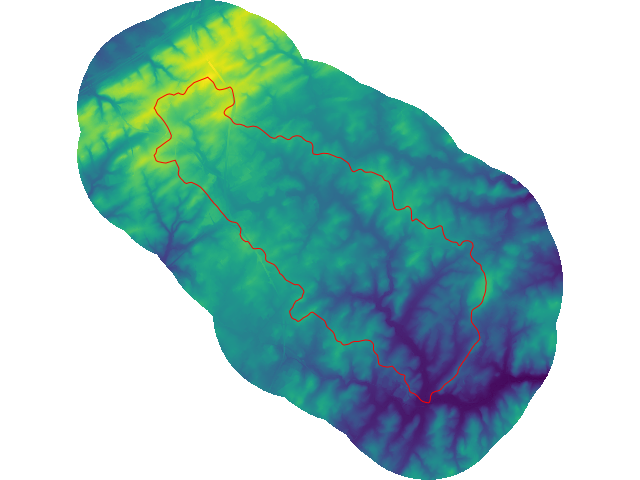

In [27]:
##print basins in grass @ Regional scale to confirm data and extent
gs.parse_command('g.region',vector = 'tmp_bsn_buffer', align = b_dems[0])
gs.run_command('d.erase')
gs.run_command('d.rast', map= b_dems[0])
gs.run_command('d.vect', map= basins,color='red',fill_color='None')
Image(filename="map.png")

## Delete Source Files (optional)

In [ ]:
import shutil
if auto_delete is True:
    #remove all files to save space
    remove_grass_data(grass_maps,'all','raster') #update 'None' with map name or type (i.e. 'raster' or 'vector')
    remove_grass_data(grass_maps,'all','vector') #update 'None' with map name or type (i.e. 'raster' or 'vector')
    #delete temp files
    shutil.rmtree(pl.Path('/home')/'grassdata'/Location/Mapset/'.tmp')
    os.makedirs(pl.Path('/home')/'grassdata'/Location/Mapset/'.tmp')

## Align to specific grid (optional)

## END